Check how rescale parameter in the arch_model functions


In [1]:
#VaR tests and vizualization
from scipy.stats import *
from scipy import stats 
from typing import Union, List, Literal, TypeAlias
import numpy as np
import numpy.typing as npt
import pandas as pd
from functools import wraps, partial
from arch import arch_model
import matplotlib.pyplot as plt

from Vares_simulations import *

from Vares import _terminal_returns, historical_var

Vares.ENABLE_TIMING = False

import pickle

#import the USD data 
with open('prices_usd.pkl', 'rb') as f: 
    prices_usd = pickle.load(f)

with open('original_returns_usd.pkl', 'rb') as f: 
    original_returns_usd = pickle.load(f)

with open('log_returns_usd.pkl', 'rb') as f: 
    log_returns_usd = pickle.load(f)    

original_returns_usd_scaled = original_returns_usd * 100
log_returns_usd_scaled = log_returns_usd * 100

In [2]:
#check that using the most regular GARCH(1, 1) driven by normal distribution

#1. Do with the resclaed input data 
#2. Do it with the rescaled input data + rescale='false'
#3. Do it the rescaled input data + devide by internal scaling 
#4-6 same but with regular (non-scaled) data

#check that on the regular graph (2 pair for scaled and non-scaled data)
#then check that on the price graph 

def fit_garch(returns, rescaling, horizon=10):
    am = arch_model(returns, vol='Garch', dist='normal', rescale=rescaling)
    result = am.fit(disp='off')
    forecast = result.forecast(horizon=horizon)
    mu = result.params.get("mu", 0)
    sigma2 = forecast.variance.values[0]
    sigma = sigma2 ** (1/2)
    parameters = GBMParams(volatility=sigma, mean=mu)

    return parameters

def get_terminal_returns(returns, parameters): 
        _terminal = solve_local_vol_gbm_log(parameters, 10, n_paths=50_000)
        VaR = historical_var(_terminal, alpha=0.01) 

        return VaR

In [38]:
def fit_GARCH_VaR(returns, garch_simulation: callable, lag=365, **kwargs): 
    time_series_length = returns.shape[0]
    avialable_lenth = time_series_length - lag
    VaRs = [0] * lag

    for t in range(avialable_lenth): 
        returns_sliced = returns[t:t+365]
        VaRs.append(garch_simulation(returns_sliced, **kwargs).item())

    return VaRs

def turn_var_into_real_terms(var_array, prices):
    return [np.exp(log_delta / 100) * price for log_delta, price in zip(var_array, prices)]

In [4]:
start = 360
lag = 365 

log_returns_usd_scaled_sliced = log_returns_usd_scaled[start:start+lag+1]

In [5]:
#1 
params1 = fit_garch(log_returns_usd_scaled_sliced, rescaling=False)
print(params1)

GBMParams(volatility=array([0.53150591, 0.53795744, 0.54393221, 0.5494708 , 0.55460952,
       0.55938095, 0.56381448, 0.56793669, 0.57177166, 0.57534131]), mean=np.float64(-0.01650353426235975))


In [6]:
#2
params2 = fit_garch(log_returns_usd_scaled_sliced, rescaling=True)
print(params2)

GBMParams(volatility=array([0.53150591, 0.53795744, 0.54393221, 0.5494708 , 0.55460952,
       0.55938095, 0.56381448, 0.56793669, 0.57177166, 0.57534131]), mean=np.float64(-0.01650353426235975))


In [7]:
#3. 
def fit_garch_scaled(returns, rescaling, horizon=10):
    am = arch_model(returns, vol='Garch', dist='normal', rescale=rescaling)
    result = am.fit(disp='off')
    s = result.scale

    forecast = result.forecast(horizon=horizon)
    mu = result.params.get("mu", 0)
    sigma2_scaled = forecast.variance.values[0]
    sigma2 = sigma2_scaled / (s ** 2)
    sigma = sigma2 ** (1/2)
    parameters = GBMParams(volatility=sigma, mean=mu)

    return parameters

params3 = fit_garch_scaled(log_returns_usd_scaled_sliced, rescaling=True)
print(params3)

GBMParams(volatility=array([0.53150591, 0.53795744, 0.54393221, 0.5494708 , 0.55460952,
       0.55938095, 0.56381448, 0.56793669, 0.57177166, 0.57534131]), mean=np.float64(-0.01650353426235975))


In [48]:
def tests_GARCH_simulation(returns, rescaling, change_scale=False, seed=1, horizon=10, n_paths=50_000, granularity=1, alpha=0.01): 
    model = arch_model(returns, vol='GARCH', p=1, o=0, q=1, dist='normal', rescale=rescaling)
    results = model.fit(disp='off')
    forecast = results.forecast(horizon=horizon)
    mu = results.params.get("mu", 0)
    if change_scale: 
        s = results.scale
        sigma2_scaled = forecast.variance.values[0]
        sigma2 = sigma2_scaled / (s ** 2)
        sigma = sigma2 ** (1/2)
        print(f'change scale is {change_scale}')
    else: 
        sigma2 = forecast.variance.values[0]
        sigma = sigma2 ** (1/2) 

    parameters = SimParams(volatility=sigma, mean=mu)

    # _ = solve_local_vol_gbm(parameters, 10, n_paths=n_paths)
    sim_returns = solve_local_vol_gbm_log(parameters, 10, n_paths=n_paths, seed=seed)

    # plt.hist(sim_returns, bins=50)
    # plt.show()

    VaR = historical_var(sim_returns, alpha)
    
    return VaR

In [23]:
vars1 = fit_GARCH_VaR(log_returns_usd_scaled, tests_GARCH_simulation, rescaling=False, change_scale=False)
vars2 = fit_GARCH_VaR(log_returns_usd_scaled, tests_GARCH_simulation, rescaling=True, change_scale=False)
vars3 = fit_GARCH_VaR(log_returns_usd_scaled, tests_GARCH_simulation, rescaling=True, change_scale=True)

In [27]:
np_vars1 = np.array(vars1)
np_vars2 = np.array(vars2)
np_vars3 = np.array(vars3)

In [28]:
_vars12 = np_vars1 - np_vars2
_vars23 = np_vars2 - np_vars3
_vars13 = np_vars1 - np_vars3
print(np.std(_vars12), np.std(_vars23), np.std(_vars13))
#they are identical

0.0 0.0 0.0


The unscaled data

In [29]:
vars4 = fit_GARCH_VaR(log_returns_usd, tests_GARCH_simulation, rescaling=False, change_scale=False)
vars5 = fit_GARCH_VaR(log_returns_usd, tests_GARCH_simulation, rescaling=True, change_scale=False)
vars6 = fit_GARCH_VaR(log_returns_usd, tests_GARCH_simulation, rescaling=True, change_scale=True)

6.23673413989973 6.176565624728524 0.553281615962079


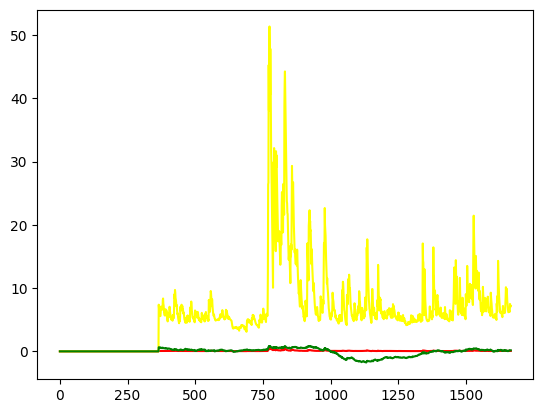

In [34]:
np_vars4 = np.array(vars4)
np_vars5 = np.array(vars5)
np_vars6 = np.array(vars6)
_vars45 = np_vars4 - np_vars5
_vars56 = np_vars5 - np_vars6
_vars46 = np_vars4 - np_vars6
print(np.std(_vars45), np.std(_vars56), np.std(_vars46))

plt.plot(np_vars4, color='red')
plt.plot(np_vars5, color='yellow')
plt.plot(np_vars6, color='green')
plt.show()

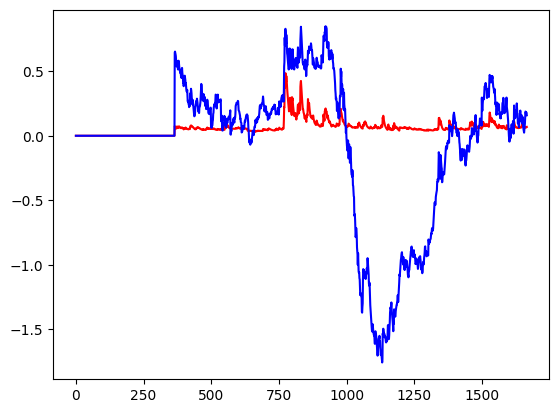

In [40]:
plt.plot(np_vars4, color='red')
plt.plot(np_vars6, color='blue')

In [45]:
def normal_GARCH_simulation(returns, horizon=10, n_paths=50_000, granularity=1, alpha=0.01): 
    model = arch_model(returns, vol='GARCH', p=1, o=0, q=1, dist='normal')
    results = model.fit(disp='off')
    forecast = results.forecast(horizon=horizon)
    mu = results.params.get("mu", 0)
    sigma2 = forecast.variance.values[0]
    sigma = sigma2 ** (1/2) #garch model estimates the variance of the underlyinh sample
    # nu = results.params.get('nu', 0)
    parameters = SimParams(volatility=sigma, mean=mu)

    # _ = solve_local_vol_gbm(parameters, 10, n_paths=n_paths)
    sim_returns = solve_local_vol_gbm_log(parameters, 10, n_paths=n_paths, seed=1)

    # plt.hist(sim_returns, bins=50)
    # plt.show()

    VaR = historical_var(sim_returns, alpha)
    
    return VaR

vars7 = fit_GARCH_VaR(log_returns_usd, normal_GARCH_simulation)

d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 7.508e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 7.505e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
d:\Users\alexa\A

0.0


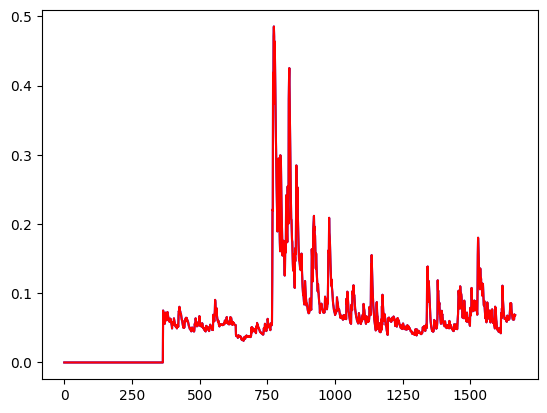

In [46]:
np_vars7 = np.array(vars7)

plt.plot(np_vars7, color='blue')
plt.plot(np_vars4, color='red')
a = np_vars7 - np_vars4
print(np.std(a))

In [47]:
#default option is rescaling false, and rescale true for sure messes things up 

In [71]:
log_returns_usd_sliced = log_returns_usd[start: start+lag]

test1 = tests_GARCH_simulation(log_returns_usd_sliced, rescaling=True, change_scale=True)
test2 = tests_GARCH_simulation(log_returns_usd_sliced, rescaling=False, change_scale=False)
test3 = test1 = tests_GARCH_simulation(log_returns_usd_sliced, rescaling=True, change_scale=False)

print(test1/100)
print(test2)
print(test3/100)

change scale is True
0.04324123930729191
0.04383767554006142
0.04324123930729191


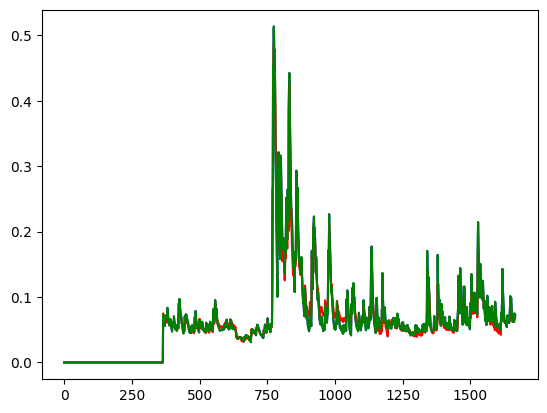

0.0


In [75]:
np_vars5_down = np_vars5 / 100
np_vars1_down = np_vars1 / 100
plt.plot(np_vars5_down, color='blue')
plt.plot(np_vars4, color='red')
plt.plot(np_vars1_down, color='green')
plt.show()

a = np_vars1_down - np_vars5_down
print(np.std(a))

In [77]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(y=np_vars5_down, mode='lines', name='np_vars5_down', line=dict(color='blue')))  # [web:3]
fig.add_trace(go.Scatter(y=np_vars4,      mode='lines', name='np_vars4',      line=dict(color='red')))   # [web:3]
fig.add_trace(go.Scatter(y=np_vars1_down, mode='lines', name='np_vars1_down', line=dict(color='green'))) # [web:3]

fig.update_layout(template='plotly_white', showlegend=True)  # [web:3]
fig.show()  # [web:3]

a = np_vars4 - np_vars5_down
print(np.std(a))

0.009486992593361245


In [80]:
#test for the significance of the results 
t_stat, p_val = stats.ttest_ind(np_vars4, np_vars5_down, equal_var=False, alternative='two-sided')
print(f"Welch t-test: t = {t_stat:.4f}, p = {p_val:.4g}")


Welch t-test: t = -0.5132, p = 0.6078


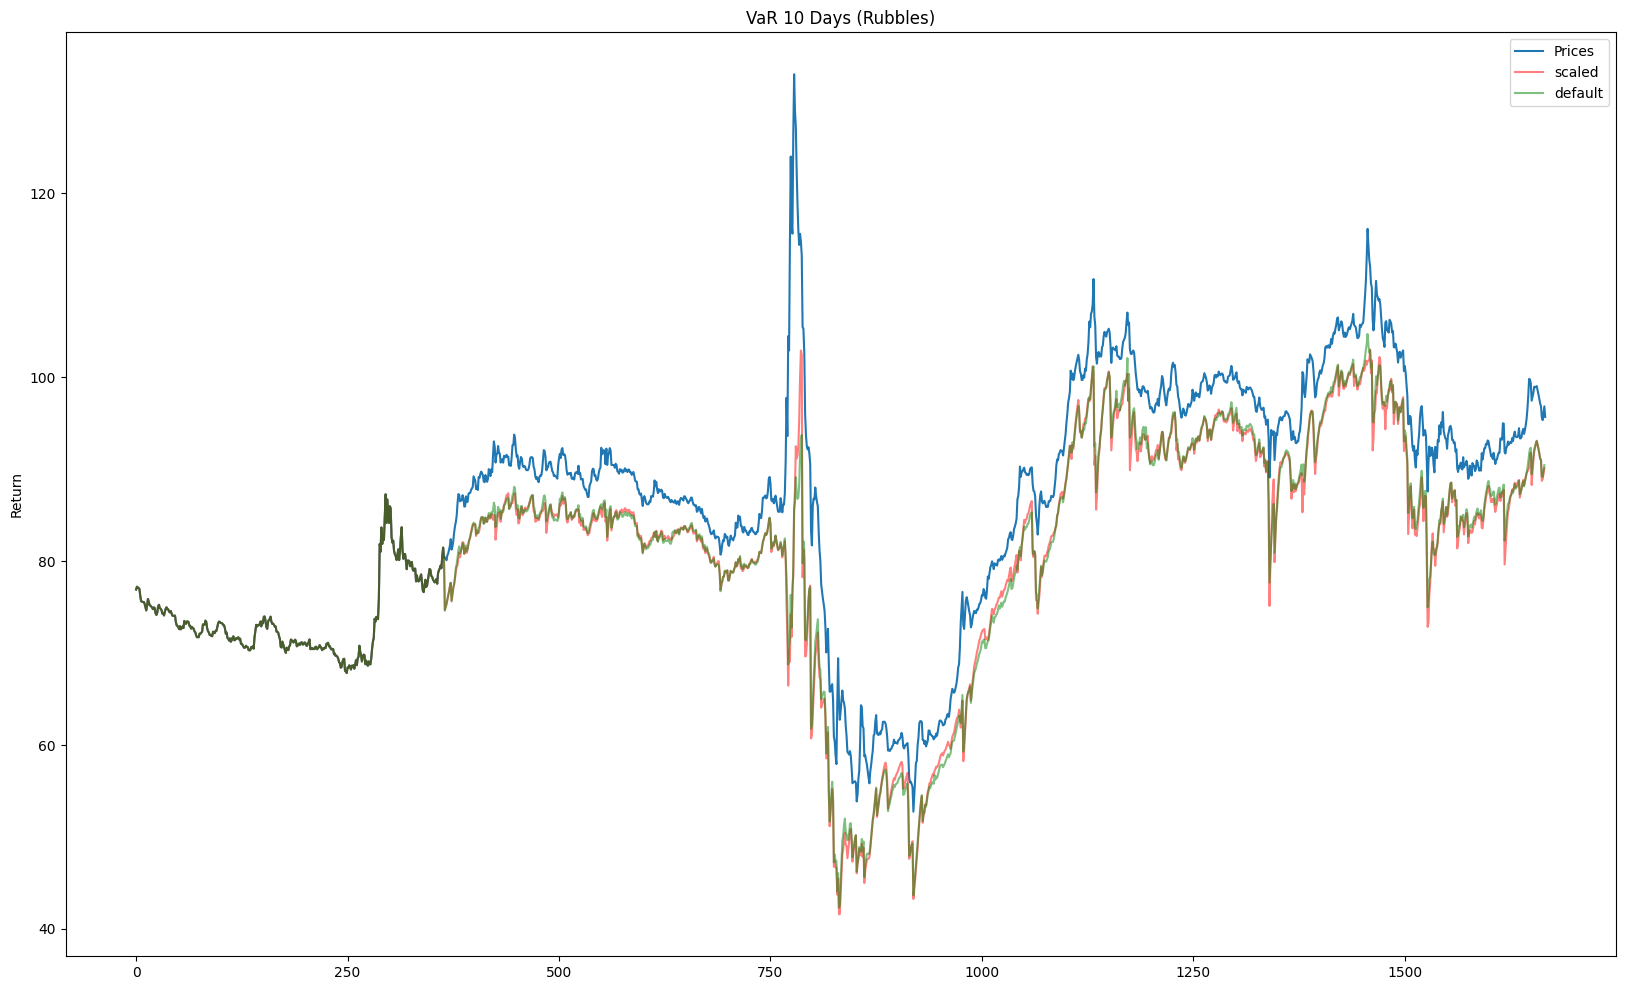

In [94]:
def turn_var_into_real_terms(var_array, prices):
    return [np.exp(log_delta) * price for log_delta, price in zip(var_array, prices)]

_np_vars4 = np.multiply(np_vars4, -1)
_np_vars1_down = np.multiply(np_vars1_down, -1)

plt.figure(figsize=(20, 12))
plt.plot(prices_usd, label='Prices')
plt.plot(turn_var_into_real_terms(_np_vars1_down, prices_usd), color='red', label='scaled', alpha=0.5)
plt.plot(turn_var_into_real_terms(_np_vars4, prices_usd), color='green', label='default', alpha=0.5)
plt.title('VaR 10 Days (Rubbles)')
plt.ylabel('Return')
plt.legend()
plt.show()

In [95]:
#test for the significance of the results 
scaled_real = turn_var_into_real_terms(_np_vars1_down, prices_usd)
scaled_default =  turn_var_into_real_terms(_np_vars4, prices_usd)


t_stat, p_val = stats.ttest_ind(_np_vars4, _np_vars1_down, equal_var=False, alternative='two-sided')
print(f"Welch t-test: t = {t_stat:.4f}, p = {p_val:.4g}")


Welch t-test: t = 0.5132, p = 0.6078
